In [53]:
from langchain.agents import create_agent
from langchain_core.tools import Tool
from langchain_huggingface import HuggingFaceEndpointEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,END,add_messages
from typing import Annotated,Sequence
from typing_extensions import TypedDict
from langchain_core.messages import HumanMessage,AIMessage,BaseMessage
from langgraph.prebuilt import create_react_agent


In [40]:
#retriever
docs=WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=20)
chunks=splitter.split_documents(docs)

embeddings = HuggingFaceEndpointEmbeddings(
    repo_id="sentence-transformers/all-MiniLM-L6-v2",
    task="feature-extraction"
)
store=FAISS.from_documents(chunks,embeddings)
retriever= store.as_retriever()
retriever


VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEndpointEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x7f3096d6b020>, search_kwargs={})

In [41]:
def retriever_func(query):
    print("using retriever tool ")
    response=retriever.invoke(query)
    return "/n".join(doc.page_content for doc in response)

In [42]:
retriever_func("what is agents?")

using retriever tool 


"Weng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/./nBuilding agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview#\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:/nPlanning is essentially in order to optimize believability at the moment vs in time.\nPrompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1)\nRelationships between agents and observations of one agent by another are all taken into consideration for planning and reacting.\nEnvironment information is present in a tree structure.\n\n\n\n\n\nThe generati

In [85]:

retriever_tool = Tool(
    name="ReAct_retriever_tool",
    description="Use this tool to fetch relevant knowledge base info",  # More descriptive
    func=retriever_func
)

In [86]:
wiki=WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results=1, doc_content_chars_max=500))
wiki

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/media/shaymaa/New Volume/AI udemy/AgenticAIworkspace/venv/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=500))

In [87]:
tools=[retriever_tool,wiki]

In [ ]:
import os 
from dotenv import load_dotenv
load_dotenv
os.environ["GROQ_API_KEY"]=os.getenv("Groq_Api_Key")
llm=ChatGroq(model="llama-3.3-70b-versatile")

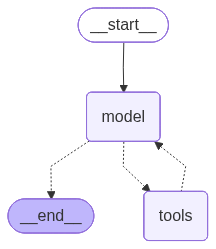

In [89]:
agent=create_agent(llm,tools)
agent

In [90]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage],add_messages]

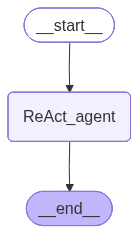

In [91]:
graph=StateGraph(State)

graph.add_node("ReAct_agent",agent)

graph.set_entry_point("ReAct_agent")
graph.add_edge("ReAct_agent",END)


builder=graph.compile()

builder


In [92]:
if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = builder.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)

using retriever tool 

✅ Final Answer:
 An agent loop refers to a system where an autonomous agent, powered by a large language model (LLM), can perform tasks independently and make decisions based on its environment and observations. According to Wikipedia, an autonomous agent is an artificial intelligence (AI) system that can perform complex tasks independently. In the context of LLM-powered autonomous agents, the agent loop involves the LLM functioning as the agent's brain, complemented by key components such as planning, relationships between agents, and environment information. This allows the agent to optimize its actions and reactions in real-time, creating a believable and interactive experience.
